<a href="https://colab.research.google.com/github/Akshit-afk-dot/AH-Visual/blob/main/VGGNet16_BCCD_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VGGNet-16 on Blood Cell Images (BCCD) Dataset
### Deep Learning Assignment

**Pipeline:** Implement → Train → Validate → Test → Evaluate → Report

**Evaluation Metrics:** Accuracy, F1, AUC-ROC, Confusion Matrix

**Dataset:** 12,500 microscopic blood cell images | 4 classes: Eosinophil, Lymphocyte, Monocyte, Neutrophil

---

## Step 0: Setup & GPU Check

In [ ]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {DEVICE}")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4
Memory: 15.6 GB

Using device: cuda


## Step 1: Install Dependencies & Download Dataset

In [ ]:
!pip install -q kaggle

from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API configured!")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle (5).json
Kaggle API configured!


In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = 'Akshit.Vergil'
os.environ['KAGGLE_KEY'] = 'KGAT_f9bef36cc9d5ba927da53de485a6e4e7'

!kaggle datasets download -d paultimothymooney/blood-cells
!unzip -q blood-cells.zip -d blood_cells
print("Done")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
blood-cells.zip: Skipping, found more recently modified local copy (use --force to force download)
replace blood_cells/dataset-master/dataset-master/Annotations/BloodImage_00000.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Done


In [ ]:

!kaggle datasets download -d paultimothymooney/blood-cells
!unzip -q blood-cells.zip -d blood_cells
print("Dataset downloaded and extracted!")

import os
for root, dirs, files_list in os.walk('blood_cells'):
    level = root.replace('blood_cells', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        subindent = ' ' * 2 * (level + 1)
        for f in files_list[:3]:
            print(f'{subindent}{f}')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
blood-cells.zip: Skipping, found more recently modified local copy (use --force to force download)
replace blood_cells/dataset-master/dataset-master/Annotations/BloodImage_00000.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Step 2: Imports & Configuration

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)
from sklearn.preprocessing import label_binarize

CONFIG = {
    'img_size'    : 224,
    'batch_size'  : 32,
    'num_epochs'  : 15,
    'lr'          : 1e-4,
    'weight_decay': 1e-4,
    'num_classes' : 4,
    'val_split'   : 0.15,
    'test_split'  : 0.15,
    'seed'        : 42,
    'patience'    : 5,
    'save_path'   : 'vgg16_bccd_best.pth'
}

CLASS_NAMES = ['Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])

print("Configuration set:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

## Step 3: Data Loading & Augmentation

In [ ]:

POSSIBLE_PATHS = [
    'blood_cells/dataset2-master/dataset2-master/images/TRAIN',
    'blood_cells/dataset-master/dataset2-master/images/TRAIN',
    'blood_cells/archive/dataset2-master/images/TRAIN',
]

DATA_DIR = None
for p in POSSIBLE_PATHS:
    if os.path.exists(p):
        DATA_DIR = p
        break

if DATA_DIR is None:
    for root, dirs, _ in os.walk('blood_cells'):
        if set(dirs) & {'EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL'}:
            DATA_DIR = root
            break

print(f"Data directory: {DATA_DIR}")
print("Classes found:", os.listdir(DATA_DIR))

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
print(f"Total images: {len(full_dataset)}")
print(f"Classes: {full_dataset.classes}")
print(f"Class to index: {full_dataset.class_to_idx}")


from collections import Counter
label_counts = Counter(full_dataset.targets)
for idx, count in sorted(label_counts.items()):
    print(f"  {full_dataset.classes[idx]}: {count} images")

In [ ]:

total = len(full_dataset)
n_test  = int(total * CONFIG['test_split'])
n_val   = int(total * CONFIG['val_split'])
n_train = total - n_val - n_test

train_set, val_set, test_set = random_split(
    full_dataset,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(CONFIG['seed'])
)


val_set.dataset  = datasets.ImageFolder(DATA_DIR, transform=val_transforms)
test_set.dataset = datasets.ImageFolder(DATA_DIR, transform=val_transforms)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

train_loader = DataLoader(train_set, batch_size=CONFIG['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
print("DataLoaders ready!")

## Step 4: Visualise Sample Images

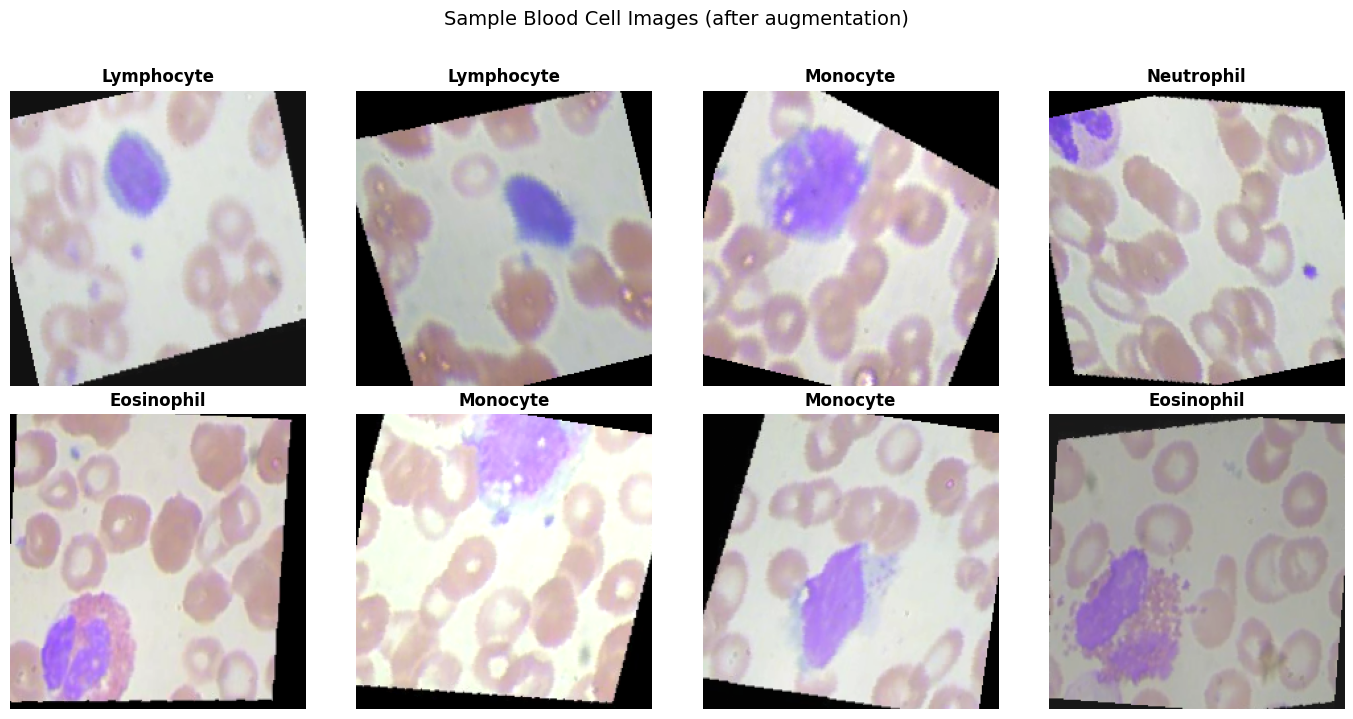

In [ ]:
def denormalize(tensor):
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(CLASS_NAMES[labels[i].item()], fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Blood Cell Images (after augmentation)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Build VGGNet-16 Model (Transfer Learning)

In [ ]:
def build_vgg16(num_classes=4, freeze_features=True):
    """
    Load pretrained VGG-16 and replace the classifier head.
    Strategy: freeze convolutional layers, train only the classifier.
    """
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)


    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.4),
        nn.Linear(1024, num_classes)
    )

    return model

model = build_vgg16(num_classes=CONFIG['num_classes']).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nClassifier head:\n{model.classifier}")

Total parameters:     121,678,660
Trainable parameters: 106,963,972
Frozen parameters:    14,714,688

Classifier head:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=1024, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.4, inplace=False)
  (6): Linear(in_features=1024, out_features=4, bias=True)
)


## Step 6: Loss, Optimizer & Scheduler

In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['num_epochs'], eta_min=1e-6
)

print(f"Criterion : {criterion}")
print(f"Optimizer : {optimizer.__class__.__name__}, lr={CONFIG['lr']}")
print(f"Scheduler : CosineAnnealingLR, T_max={CONFIG['num_epochs']}")

Criterion : CrossEntropyLoss()
Optimizer : Adam, lr=0.0001
Scheduler : CosineAnnealingLR, T_max=15


## Step 7: Training Loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Eval ', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


print("Training functions defined.")

Training functions defined.


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_acc = 0.0
patience_counter = 0

print(f"Training VGGNet-16 for {CONFIG['num_epochs']} epochs on {DEVICE}\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>8}")
print('-' * 65)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    cur_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:>5} | {train_loss:>10.4f} | {train_acc:>8.2%} | {val_loss:>8.4f} | {val_acc:>6.2%} | {cur_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CONFIG['save_path'])
        print(f"          ✓ Best model saved (val_acc={best_val_acc:.2%})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['patience']:
            print(f"\nEarly stopping at epoch {epoch} (no improvement for {CONFIG['patience']} epochs)")
            break

print(f"\nTraining complete! Best Val Acc: {best_val_acc:.2%}")

## Step 8: Plot Training Curves

In [ ]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_ran, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Test Set Evaluation

In [ ]:
model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
model.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Testing'):
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"Test samples: {len(all_labels)}")

## Step 10: Metrics — Accuracy, F1, AUC-ROC

In [ ]:
test_acc = accuracy_score(all_labels, all_preds)

f1_macro  = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')

labels_bin = label_binarize(all_labels, classes=[0, 1, 2, 3])
auc_roc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')

print("="*45)
print("        TEST SET RESULTS")
print("="*45)
print(f"  Accuracy         : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  F1 (macro)       : {f1_macro:.4f}")
print(f"  F1 (weighted)    : {f1_weighted:.4f}")
print(f"  AUC-ROC (macro)  : {auc_roc:.4f}")
print("="*45)

print("\nPer-class Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## Step 11: Confusion Matrix

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: AUC-ROC Curves

In [ ]:
from itertools import cycle

colors = cycle(['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])

plt.figure(figsize=(9, 7))

for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_i = roc_auc_score(labels_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{class_name} (AUC = {auc_i:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curves — VGGNet-16 on BCCD\n(Macro AUC = {auc_roc:.4f})', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 13: Visualise Predictions on Test Samples

In [ ]:

images, labels = next(iter(test_loader))
images_gpu = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images_gpu)
    probs   = torch.softmax(outputs, dim=1)
    preds   = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(12):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    true_label = CLASS_NAMES[labels[i].item()]
    pred_label = CLASS_NAMES[preds[i].item()]
    conf       = probs[i][preds[i]].item() * 100

    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.1f}%)",
                      color=color, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Model Predictions on Test Set (Green=Correct, Red=Wrong)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 14: Save Model Weights (.pth)

In [ ]:

torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc'     : best_val_acc,
    'test_acc'         : test_acc,
    'f1_macro'         : f1_macro,
    'auc_roc'          : auc_roc,
    'config'           : CONFIG,
    'class_names'      : CLASS_NAMES,
    'history'          : history,
}, 'vgg16_bccd_final.pth')

print("Model saved to vgg16_bccd_final.pth")
print(f"File size: {os.path.getsize('vgg16_bccd_final.pth') / 1e6:.1f} MB")

In [ ]:

from google.colab import files
files.download('vgg16_bccd_final.pth')

## Step 15: Final Summary (for Report)

In [ ]:
print("="*55)
print("    FINAL RESULTS SUMMARY — VGGNet-16 on BCCD")
print("="*55)
print(f"  Architecture     : VGGNet-16 (Transfer Learning)")
print(f"  Dataset          : Blood Cell Images (BCCD)")
print(f"  Classes          : {', '.join(CLASS_NAMES)}")
print(f"  Train / Val / Test: {n_train} / {n_val} / {n_test}")
print(f"  Epochs trained   : {len(history['train_loss'])}")
print(f"  Best Val Acc     : {best_val_acc:.2%}")
print("─"*55)
print(f"  Test Accuracy    : {test_acc:.4f}")
print(f"  F1 Score (macro) : {f1_macro:.4f}")
print(f"  F1 (weighted)    : {f1_weighted:.4f}")
print(f"  AUC-ROC (macro)  : {auc_roc:.4f}")
print("="*55)
print("\nFigures saved:")
for fig_name in ['sample_images.png','training_curves.png','confusion_matrix.png','roc_curves.png','predictions.png']:
    exists = '✓' if os.path.exists(fig_name) else '✗'
    print(f"  {exists} {fig_name}")